# 07 · Bayes Teoremi (Bayes' Theorem)
**Probability Lab** · Bayes Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Koşullu olasılığı ($P(A\mid B)$) zaten biliyoruz. Bayes Teoremi, bunu **tersine çevirmemizi**
> sağlıyor: $P(B\mid A)$'yı biliyorsak, $P(A\mid B)$'yi hesaplayabiliyoruz. Bu basit görünen
> ters çevirme, modern istatistik ve makine öğrenmesinin büyük bir kısmının temelini oluşturuyor —
> tıbbi teşhis, spam filtreleme, A/B testi, Naive Bayes sınıflandırıcı, hatta derin öğrenmedeki
> bazı düzenlileştirme (regularization) teknikleri bile Bayesyen mantığa dayanıyor.

**Önkoşul:** Koşullu Olasılık, Beta/Binomial Dağılımlar (03), Beklenti/Varyans (05)  
**Veri:**  
- `ab_data.csv` — Web sitesi A/B testi (294.478 kullanıcı, `group`, `converted`)  
- `cookie_cats.csv` — Mobil oyun A/B testi (90.189 kullanıcı, `version`, `retention_7`)  
- `creditcard.csv` — Kredi kartı sahtekarlık tespiti (284.807 işlem, aşırı dengesiz sınıflar)  
**Araçlar:** Python (numpy, scipy, scikit-learn), R (ggplot2), SQL (DuckDB)

---
## 1 · Sezgi: Bayes Teoremi Neden Var?

Diyelim ki bir hastalık testi pozitif çıktı. Doğal olarak sorduğun soru şu:
**"Testim pozitif çıktığına göre, gerçekten hasta olma olasılığım nedir?"** — yani $P(\text{Hasta} \mid \text{Test+})$.

Ama laboratuvarların/araştırmaların sana verdiği bilgi genelde **tersi yöndedir**:
**"Hasta olanların yüzde kaçında test pozitif çıkıyor?"** — yani $P(\text{Test+} \mid \text{Hasta})$.

Bu iki olasılık **aynı şey değildir** ve birbirine karıştırılması "savcı yanılgısı" (prosecutor's
fallacy) gibi ciddi hatalara yol açar. Bayes Teoremi, elindeki $P(\text{Test+}\mid\text{Hasta})$
bilgisinden, gerçekten merak ettiğin $P(\text{Hasta}\mid\text{Test+})$'ye geçmeni sağlayan köprüdür.

---
## 2 · Formal Türetim

Koşullu olasılığın tanımından başlıyoruz:
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)} \qquad P(B \mid A) = \frac{P(A \cap B)}{P(A)}$$

Her iki denklemde de pay aynı ($P(A \cap B)$). İkinci denklemi $P(A\cap B)$ için çözersek:
$$P(A \cap B) = P(B \mid A) \cdot P(A)$$

Bunu birinci denklemde yerine koyarsak, **Bayes Teoremi**'ni elde ederiz:
$$\boxed{P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}}$$

Sadece cebirsel bir yeniden düzenleme — ama sonuçları devrim niteliğinde.

---
## 3 · Terminoloji: Prior, Likelihood, Evidence, Posterior

$$\underbrace{P(A \mid B)}_{\text{Posterior}} = \frac{\overbrace{P(B \mid A)}^{\text{Likelihood}} \cdot \overbrace{P(A)}^{\text{Prior}}}{\underbrace{P(B)}_{\text{Evidence}}}$$

| Terim | Anlamı | Örnek (Tıbbi Test) |
|---|---|---|
| **Prior** $P(A)$ | Veriyi görmeden ÖNCEKİ inancımız | Hastalığın popülasyondaki yaygınlığı (%1) |
| **Likelihood** $P(B\mid A)$ | $A$ doğruysa, bu veriyi gözlemleme olasılığı | Hasta birinin testte pozitif çıkma olasılığı (sensitivite) |
| **Evidence** $P(B)$ | Veriyi gözlemleme olasılığı (genel, normalize sabiti) | Herhangi birinin testte pozitif çıkma olasılığı |
| **Posterior** $P(A\mid B)$ | Veriyi gördükten SONRAKİ güncellenmiş inancımız | Test pozitifken gerçekten hasta olma olasılığı |

**Evidence'ı açarsak** (tam olasılık kanunu ile):
$$P(B) = P(B \mid A)P(A) + P(B \mid A^c)P(A^c)$$

Bu, notlarındaki "toplam beklenti/tümleyen kuralı" ile aynı mantık — tüm olası senaryoları toplayıp normalize ediyoruz.

---
## 4 · Klasik Örnek: Tıbbi Test Paradoksu

**Senaryo:** Bir hastalığın popülasyondaki yaygınlığı %1 ($P(\text{Hasta})=0.01$). Test, hasta
olanların %95'inde pozitif çıkıyor (sensitivite: $P(+\mid\text{Hasta})=0.95$), sağlıklı olanların
%90'ında negatif çıkıyor (spesifite: $P(-\mid\text{Sağlıklı})=0.90$, yani $P(+\mid\text{Sağlıklı})=0.10$).

**Soru:** Testin pozitif çıktığı biri gerçekten hasta olma olasılığı nedir?

$$P(\text{Hasta}\mid +) = \frac{P(+\mid\text{Hasta})P(\text{Hasta})}{P(+\mid\text{Hasta})P(\text{Hasta}) + P(+\mid\text{Sağlıklı})P(\text{Sağlıklı})}$$
$$= \frac{0.95 \times 0.01}{0.95 \times 0.01 + 0.10 \times 0.99} = \frac{0.0095}{0.1085} \approx 0.0876$$

**Şaşırtıcı sonuç: sadece %8.76!** Test "%95 doğru" görünse de, hastalık o kadar nadir ki
(prior çok küçük), pozitif çıkanların çoğu aslında **yanlış pozitif**. Bunu aşağıda "doğal
frekans" ızgarasıyla görselleştireceğiz — sayılarla çalışmak, oranlarla çalışmaktan çok daha
sezgisel çünkü.

10.000 kişilik popülasyon:
  Hasta (n=100): 95 Doğru Pozitif, 5 Yanlış Negatif
  Sağlıklı (n=9900): 989 Yanlış Pozitif, 8911 Doğru Negatif

Test pozitif çıkan TOPLAM: 1084
Bunların GERÇEKTEN hasta olanı: 95
P(Hasta | Test+) = 95/1084 = 0.0876


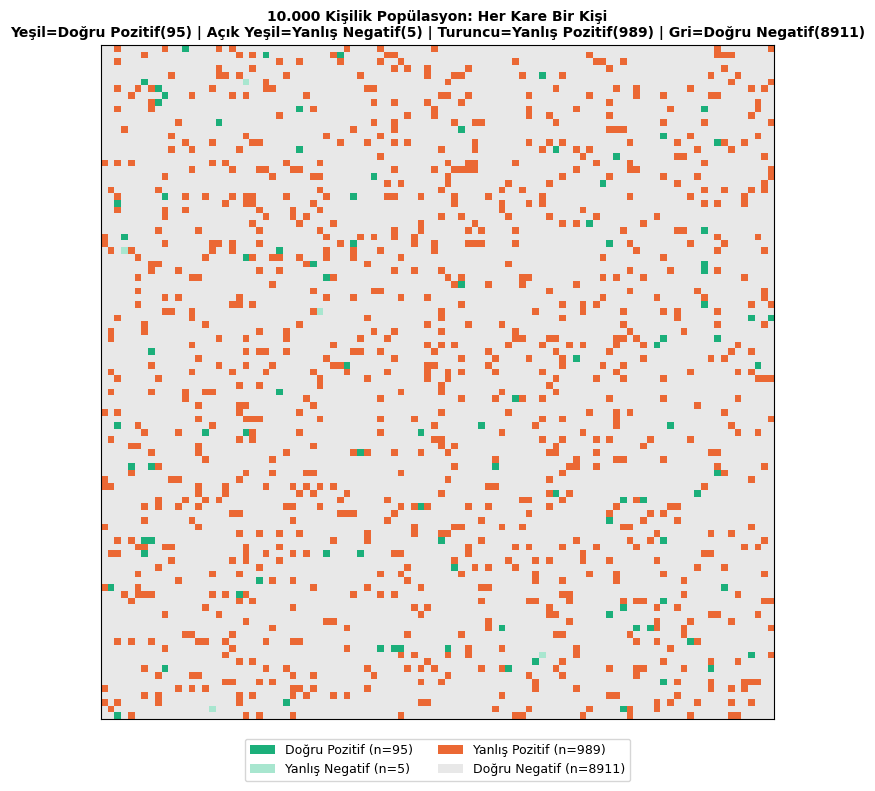


GÖRSEL YORUM: Turuncu (Yanlış Pozitif) kareler, yeşil (Doğru Pozitif) karelerden
çok daha fazla! Çünkü sağlıklı popülasyon (9900) hasta popülasyonundan (100)
o kadar büyük ki, %10'luk küçük bir yanlış-pozitif oranı bile mutlak sayıda hastaları geçiyor.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 10.000 kisilik bir populasyonu "dogal frekans" olarak gorsellestirelim (Gigerenzer yontemi)
N = 10000
prior = 0.01
sens = 0.95   # P(+|Hasta)
spec = 0.90   # P(-|Saglikli)

n_hasta = int(N * prior)
n_saglikli = N - n_hasta

tp = int(n_hasta * sens)          # Hasta + Test Pozitif (Dogru Pozitif)
fn = n_hasta - tp                  # Hasta + Test Negatif (Yanlis Negatif)
fp = int(n_saglikli * (1 - spec))  # Saglikli + Test Pozitif (Yanlis Pozitif)
tn = n_saglikli - fp                # Saglikli + Test Negatif (Dogru Negatif)

print(f"10.000 kişilik popülasyon:")
print(f"  Hasta (n={n_hasta}): {tp} Doğru Pozitif, {fn} Yanlış Negatif")
print(f"  Sağlıklı (n={n_saglikli}): {fp} Yanlış Pozitif, {tn} Doğru Negatif")
print(f"\nTest pozitif çıkan TOPLAM: {tp + fp}")
print(f"Bunların GERÇEKTEN hasta olanı: {tp}")
print(f"P(Hasta | Test+) = {tp}/{tp+fp} = {tp/(tp+fp):.4f}")

# Izgara gorsellestirme: 100x100 = 10.000 kare
rng = np.random.default_rng(42)
categories = np.array(['TP'] * tp + ['FN'] * fn + ['FP'] * fp + ['TN'] * tn)
rng.shuffle(categories)
grid = categories.reshape(100, 100)

color_map = {'TP': 0, 'FN': 1, 'FP': 2, 'TN': 3}
grid_num = np.vectorize(color_map.get)(grid)
cmap = ListedColormap(['#1baf7a', '#a8e6cf', '#eb6834', '#e8e8e8'])

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(grid_num, cmap=cmap, interpolation='nearest')
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'10.000 Kişilik Popülasyon: Her Kare Bir Kişi\n'
             f'Yeşil=Doğru Pozitif({tp}) | Açık Yeşil=Yanlış Negatif({fn}) | '
             f'Turuncu=Yanlış Pozitif({fp}) | Gri=Doğru Negatif({tn})', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#1baf7a', label=f'Doğru Pozitif (n={tp})'),
    Patch(facecolor='#a8e6cf', label=f'Yanlış Negatif (n={fn})'),
    Patch(facecolor='#eb6834', label=f'Yanlış Pozitif (n={fp})'),
    Patch(facecolor='#e8e8e8', label=f'Doğru Negatif (n={tn})'),
]
ax.legend(handles=legend_elems, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nGÖRSEL YORUM: Turuncu (Yanlış Pozitif) kareler, yeşil (Doğru Pozitif) karelerden")
print(f"çok daha fazla! Çünkü sağlıklı popülasyon ({n_saglikli}) hasta popülasyonundan ({n_hasta})")
print(f"o kadar büyük ki, %10'luk küçük bir yanlış-pozitif oranı bile mutlak sayıda hastaları geçiyor.")

---
## 5 · Çoklu Hipotez Bayes Teoremi

İki hipotez yerine ($A$, $A^c$) birden fazla karşılıklı dışlayan hipotez ($E_1, E_2, \dots, E_n$)
varsa, formül şöyle genelleşir:

$$P(E_i \mid O) = \frac{P(O \mid E_i)P(E_i)}{\sum_{j=1}^{n} P(O \mid E_j)P(E_j)}$$

Payda yine bir **normalizasyon sabiti** — tüm hipotezlerin ağırlıklı olabilirliğini toplayıp
olasılıkların 0-1 aralığında ve toplamı 1 olacak şekilde ölçeklendiriyor. Bu formül, aşağıda
göreceğimiz **Naive Bayes sınıflandırıcının** ve **MAP (Maximum A Posteriori) tahmininin**
doğrudan matematiksel temelidir.

---
## 6 · Bayes ve Öğrenme: Sıralı Güncelleme (Sequential Updating)

Bayes Teoremi'nin en güçlü yanlarından biri: **bugünün posterior'u, yarının prior'u olur.**
Yeni veri geldikçe inancını sürekli güncelleyebilirsin — sıfırdan başlamana gerek yok.

Aşağıda, gerçek olasılığı $p=0.7$ olan hileli bir paranın sonuçlarını sırayla gözlemleyip,
Beta dağılımı (Beta-Binomial eşlenik prior) ile posterior'un nasıl daraldığını ve gerçek
değere nasıl kilitlendiğini görselleştiriyoruz.

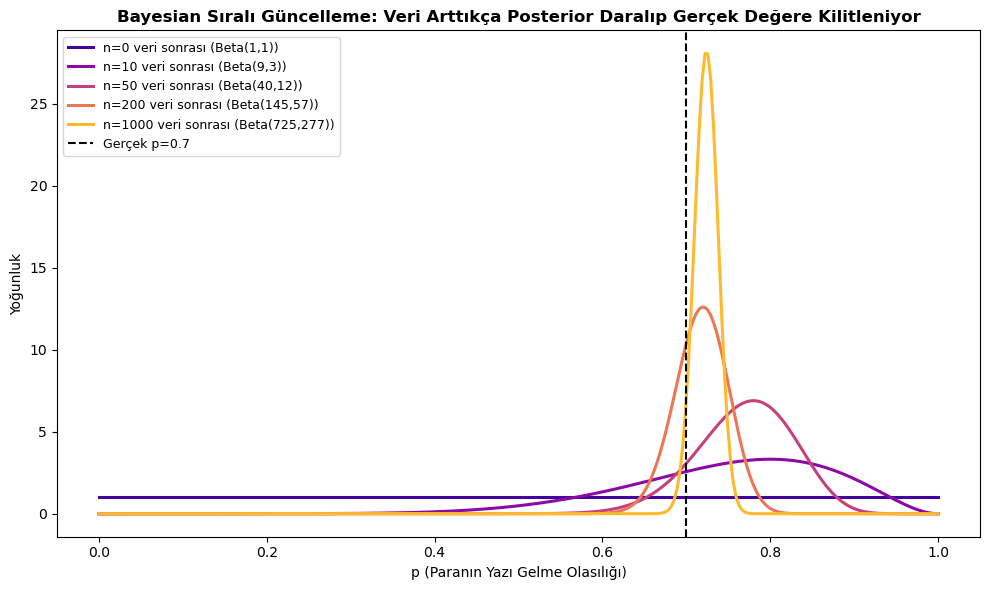

YORUM: n=0'da (sadece prior, Beta(1,1)) dağılım tamamen düz - hiçbir fikrimiz yok.
n arttıkça eğri hem daha sivri (daha az belirsiz) hem de gerçek p=0.7'ye kayıyor.
Bu tam olarak notlarındaki LLN + CLT'nin Bayesyen versiyonu: veri arttıkça inanç gerçeğe yakınsıyor.


In [5]:
import scipy.stats as stats

true_p = 0.7
rng = np.random.default_rng(11)
flips = rng.binomial(1, true_p, 1000)

checkpoints = [0, 10, 50, 200, 1000]
x = np.linspace(0, 1, 300)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(checkpoints)))

for n, color in zip(checkpoints, colors):
    successes = flips[:n].sum()
    a = 1 + successes           # Beta(1,1) prior + gozlemlenen basari
    b = 1 + (n - successes)
    ax.plot(x, stats.beta.pdf(x, a, b), color=color, linewidth=2.2, label=f'n={n} veri sonrası (Beta({a},{b}))')

ax.axvline(true_p, color='black', linestyle='--', linewidth=1.5, label=f'Gerçek p={true_p}')
ax.set_title('Bayesian Sıralı Güncelleme: Veri Arttıkça Posterior Daralıp Gerçek Değere Kilitleniyor', fontweight='bold')
ax.set_xlabel('p (Paranın Yazı Gelme Olasılığı)')
ax.set_ylabel('Yoğunluk')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("YORUM: n=0'da (sadece prior, Beta(1,1)) dağılım tamamen düz - hiçbir fikrimiz yok.")
print("n arttıkça eğri hem daha sivri (daha az belirsiz) hem de gerçek p=0.7'ye kayıyor.")
print("Bu tam olarak notlarındaki LLN + CLT'nin Bayesyen versiyonu: veri arttıkça inanç gerçeğe yakınsıyor.")

---
## 7 · Naive Bayes Sınıflandırıcısına Köprü

Çoklu hipotez formülünü bir sınıflandırma problemine uygularsak: $E_i$ yerine "sınıf $i$" ($C_i$),
$O$ yerine "gözlemlenen özellikler" ($x_1, x_2, \dots, x_k$) koyarsak:

$$P(C_i \mid x_1,\dots,x_k) \propto P(x_1,\dots,x_k \mid C_i) \cdot P(C_i)$$

"Naive" (saf) olmasının sebebi: özelliklerin birbirinden **koşullu bağımsız** olduğunu varsayması
(gerçekte doğru olmasa bile, pratikte şaşırtıcı derecede iyi çalışıyor):

$$P(x_1,\dots,x_k \mid C_i) \approx \prod_{j=1}^{k} P(x_j \mid C_i)$$

Sınıflandırma kararı: en yüksek posterior olasılığa sahip sınıfı seç — buna **MAP (Maximum A
Posteriori)** tahmini denir. Python bölümünde bunu sıfırdan kodlayacağız.

---
## 8 · Özet: Bayes Teoreminin Kullanım Alanları

| Alan | Nasıl Kullanılıyor |
|---|---|
| Tıbbi Teşhis | Test sonucundan gerçek hastalık olasılığını çıkarma |
| Spam Filtreleme | Kelime frekanslarından (Naive Bayes) spam olasılığını hesaplama |
| A/B Testi | Dönüşüm oranları için prior/posterior güncelleme (Beta-Binomial) |
| Sahtekarlık Tespiti | Nadir olay (fraud) için gerçek pozitif oranını (precision) hesaplama |
| Makine Öğrenmesi | MAP tahmini, Bayesyen optimizasyon, düzenlileştirme |
| Adli Bilim | Kanıt gücünü (likelihood ratio) prior ile birleştirme |

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Tıbbi Test Paradoksu** — Farklı prior değerleriyle posterior'un nasıl değiştiğini sistematik inceleme
2. **Kredi Kartı Sahtekarlığı** — Gerçek bir sınıflandırıcıdan Bayes posterior'u (precision) çıkarma
3. **Bayesian A/B Testi** — Beta-Binomial conjugate prior ile web sitesi dönüşüm oranı karşılaştırma
4. **Cookie Cats: Oyun İçi Retention** — Aynı yöntemi farklı bir gerçek veri setinde tekrarlama
5. **Naive Bayes'i Sıfırdan Kurma** — Çoklu hipotez formülünü gerçek bir sınıflandırıcıya dönüştürme

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🩺 Python 1 — Prior Değiştikçe Posterior Nasıl Değişir?

**Ne yapıyoruz?**  
Sensitivite (%95) ve spesifite (%90) sabit kalırken, hastalığın popülasyondaki yaygınlığını
(prior) %0.1'den %50'ye kadar değiştirip posterior'un nasıl tepki verdiğini çizeceğiz.
Bu, "prior'un posterior üzerindeki gücünü" somutlaştırıyor.

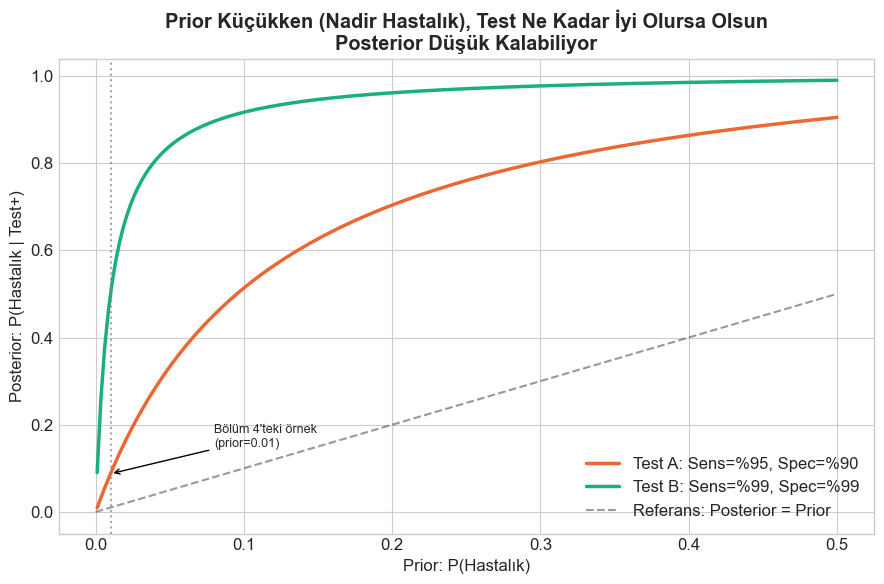

YORUM: Test B (Sens=Spec=%99) bile, prior %1'in altındayken posterior'u %50'nin üzerine
çıkaramıyor. Bu, nadir olaylarda 'ne kadar iyi test olursa olsun, prior'un gücünü
yenmesinin zor olduğunu' gösteriyor - kredi kartı sahtekarlığında da aynı sorunla karşılaşacağız.


In [7]:
def bayes_posterior(prior, sens, spec):
    p_pos_given_healthy = 1 - spec
    evidence = sens * prior + p_pos_given_healthy * (1 - prior)
    return (sens * prior) / evidence

priors = np.linspace(0.001, 0.5, 200) # prior olasılıkları 0.1%'den 50%'ye kadar
posteriors_95_90 = [bayes_posterior(p, 0.95, 0.90) for p in priors]
posteriors_99_99 = [bayes_posterior(p, 0.99, 0.99) for p in priors]  # cok daha iyi bir test

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(priors, posteriors_95_90, color='#eb6834', linewidth=2.5, label='Test A: Sens=%95, Spec=%90')
ax.plot(priors, posteriors_99_99, color='#1baf7a', linewidth=2.5, label='Test B: Sens=%99, Spec=%99')
ax.plot([0, 0.5], [0, 0.5], 'k--', alpha=0.4, label='Referans: Posterior = Prior')
ax.axvline(0.01, color='gray', linestyle=':', alpha=0.7)
ax.annotate('Bölüm 4\'teki örnek\n(prior=0.01)', xy=(0.01, bayes_posterior(0.01, 0.95, 0.90)),
            xytext=(0.08, 0.15), fontsize=9, arrowprops=dict(arrowstyle='->'))

ax.set_xlabel('Prior: P(Hastalık)')
ax.set_ylabel('Posterior: P(Hastalık | Test+)')
ax.set_title('Prior Küçükken (Nadir Hastalık), Test Ne Kadar İyi Olursa Olsun\nPosterior Düşük Kalabiliyor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: Test B (Sens=Spec=%99) bile, prior %1'in altındayken posterior'u %50'nin üzerine")
print("çıkaramıyor. Bu, nadir olaylarda 'ne kadar iyi test olursa olsun, prior'un gücünü")
print("yenmesinin zor olduğunu' gösteriyor - kredi kartı sahtekarlığında da aynı sorunla karşılaşacağız.")

---
### 💳 Python 2 — Kredi Kartı Sahtekarlığı: Gerçek Sınıflandırıcıdan Bayes Posterior'u

**Ne yapıyoruz?**  
`creditcard.csv`'de sahtekarlık (`Class=1`) son derece nadir (~%0.17). Gerçek bir Lojistik
Regresyon modeli eğitip, "Precision" metriğinin aslında **tam olarak Bayes posterior'u**
$P(\text{Fraud} \mid \text{Model 'Fraud' Dedi})$ olduğunu göstereceğiz.

Veri yüklendi: 284807 işlem, 31 sütun
Class
0    284315
1       492
Name: count, dtype: int64

P(Fraud) = PRIOR = 0.00173 (0.173%) — son derece nadir bir olay!

Confusion Matrix: TN=83410, FP=1885, FN=19, TP=129

P(Gerçekten Fraud | Model 'Fraud' Dedi) = TP/(TP+FP) = 0.0641
Karşılaştırma - Prior (hiçbir modelsiz bilgi): 0.00173
Model, posterior'u prior'a göre ~37x artırdı!


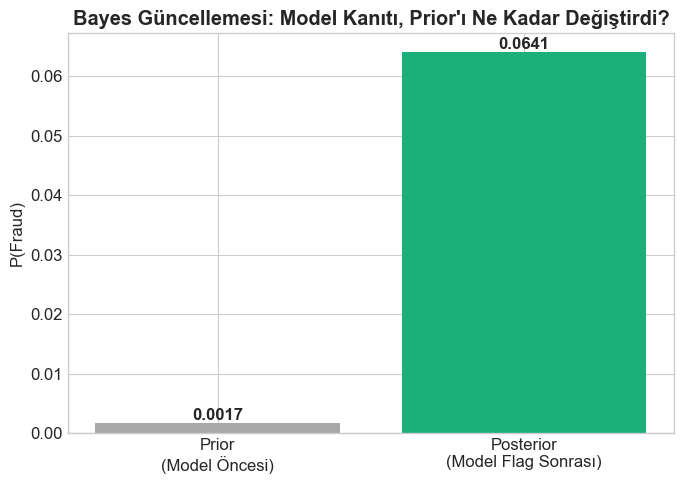

In [8]:
credit = pd.read_csv('data/creditcard.csv')
print(f"Veri yüklendi: {credit.shape[0]} işlem, {credit.shape[1]} sütun")
print(credit['Class'].value_counts())

prior_fraud = credit['Class'].mean() # prior hesabı
print(f"\nP(Fraud) = PRIOR = {prior_fraud:.5f} ({prior_fraud*100:.3f}%) — son derece nadir bir olay!")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

feature_cols = [c for c in credit.columns if c not in ['Class', 'Time']]
X = credit[feature_cols]
y = credit['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nConfusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

posterior_fraud_given_flag = tp / (tp + fp) # posterior hesabı yani modelin sahtekarlık dediği işlemlerden kaç tanesinin gerçekten sahte olduğunu gösteren oran (Precision metric)
print(f"\nP(Gerçekten Fraud | Model 'Fraud' Dedi) = TP/(TP+FP) = {posterior_fraud_given_flag:.4f}")
print(f"Karşılaştırma - Prior (hiçbir modelsiz bilgi): {prior_fraud:.5f}")
print(f"Model, posterior'u prior'a göre ~{posterior_fraud_given_flag/prior_fraud:.0f}x artırdı!")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Prior\n(Model Öncesi)', 'Posterior\n(Model Flag Sonrası)'],
       [prior_fraud, posterior_fraud_given_flag], color=['#a8a8a8', '#1baf7a'])
ax.set_ylabel('P(Fraud)')
ax.set_title('Bayes Güncellemesi: Model Kanıtı, Prior\'ı Ne Kadar Değiştirdi?', fontweight='bold')
for i, v in enumerate([prior_fraud, posterior_fraud_given_flag]):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 🅰️🅱️ Python 3 — Bayesian A/B Testi: Beta-Binomial Conjugate Güncelleme

**Ne yapıyoruz?**  
`ab_data.csv`'de kontrol (eski sayfa) ve treatment (yeni sayfa) gruplarının dönüşüm oranlarını
Bayesyen çerçevede karşılaştıracağız. Beta dağılımı Binomial ile **eşlenik (conjugate)** olduğu
için posterior güncellemesi kapalı-form bir formülle (integral almadan) yapılabiliyor:
$\text{Beta}(\alpha_0, \beta_0) \to \text{Beta}(\alpha_0 + \text{başarı}, \beta_0 + \text{başarısızlık})$

Temizlik sonrası: 286690 satır (orijinal: 294478)

Kontrol:   17220/143293 dönüşüm (0.1202) -> Posterior Beta(17221,126074)
Treatment: 17025/143397 dönüşüm (0.1187) -> Posterior Beta(17026,126373)


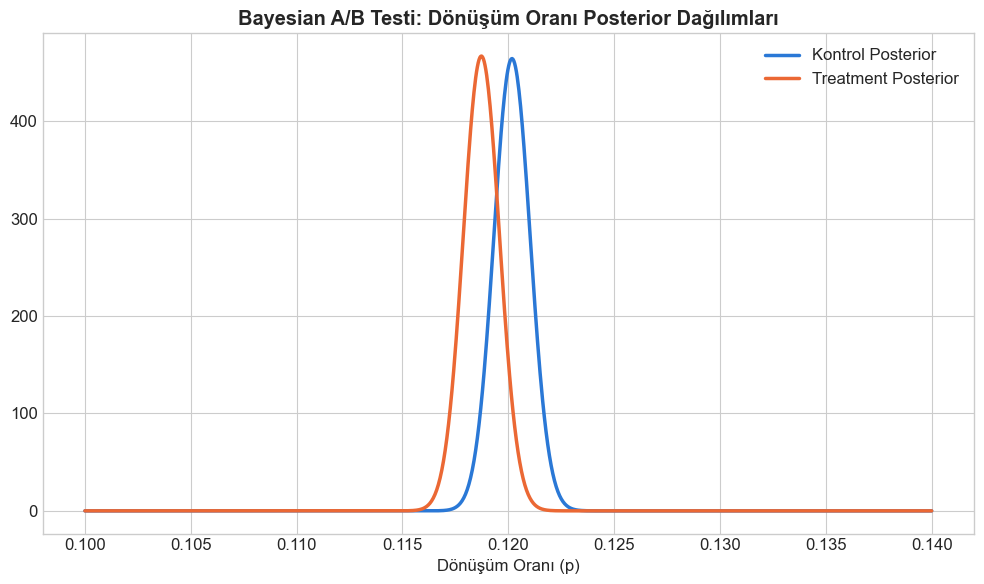


Monte Carlo ile: P(Treatment dönüşüm oranı > Kontrol) = 0.1173
YORUM: Bu olasılık %50'ye çok yakınsa (veya Kontrol lehineyse), 'yeni sayfa' varsayımı
istatistiksel olarak desteklenmiyor demektir - klasik p-value'suz bir karar verme yöntemi.


In [9]:
ab = pd.read_csv('data/ab_data.csv')
# Bilinen veri kalitesi sorunu: bazi user_id'ler hem control hem treatment'a denk geliyor - temizleyelim
tekrar_eden = ab['user_id'].value_counts()
gecerli_id = tekrar_eden[tekrar_eden == 1].index
ab_clean = ab[ab['user_id'].isin(gecerli_id)]
print(f"Temizlik sonrası: {len(ab_clean)} satır (orijinal: {len(ab)})")

control = ab_clean[ab_clean['group'] == 'control']
treatment = ab_clean[ab_clean['group'] == 'treatment']

alpha_prior, beta_prior = 1, 1  # Beta(1,1) = Uniform, hicbir onsel bilgimiz yok (prior yok)

c_success, c_total = control['converted'].sum(), len(control)
t_success, t_total = treatment['converted'].sum(), len(treatment)

alpha_c, beta_c = alpha_prior + c_success, beta_prior + (c_total - c_success)
alpha_t, beta_t = alpha_prior + t_success, beta_prior + (t_total - t_success)

print(f"\nKontrol:   {c_success}/{c_total} dönüşüm ({c_success/c_total:.4f}) -> Posterior Beta({alpha_c},{beta_c})")
print(f"Treatment: {t_success}/{t_total} dönüşüm ({t_success/t_total:.4f}) -> Posterior Beta({alpha_t},{beta_t})")

x = np.linspace(0.10, 0.14, 1000)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, stats.beta.pdf(x, alpha_c, beta_c), color='#2a78d6', linewidth=2.5, label='Kontrol Posterior')
ax.plot(x, stats.beta.pdf(x, alpha_t, beta_t), color='#eb6834', linewidth=2.5, label='Treatment Posterior')
ax.set_title('Bayesian A/B Testi: Dönüşüm Oranı Posterior Dağılımları', fontweight='bold')
ax.set_xlabel('Dönüşüm Oranı (p)')
ax.legend()
plt.tight_layout()
plt.show()

rng = np.random.default_rng(42)
samples_c = rng.beta(alpha_c, beta_c, 200000)
samples_t = rng.beta(alpha_t, beta_t, 200000)
p_treatment_better = (samples_t > samples_c).mean()
print(f"\nMonte Carlo ile: P(Treatment dönüşüm oranı > Kontrol) = {p_treatment_better:.4f}")
print("YORUM: Bu olasılık %50'ye çok yakınsa (veya Kontrol lehineyse), 'yeni sayfa' varsayımı")
print("istatistiksel olarak desteklenmiyor demektir - klasik p-value'suz bir karar verme yöntemi.")

### Python 3 - Açıklama
* Neden Monte Carlo? Çünkü "iki farklı Beta dağılımından çekilen rastgele sayılardan biri diğerinden büyük mü" sorusunun kapalı-form (formülle direkt) bir cevabı yok — ama binlerce kez simüle edip sayarsak, gerçek olasılığa çok yakın bir tahmin elde ederiz. Bu, LLN'nin (Büyük Sayılar Yasası) burada pratik bir uygulaması.

> P(Treatment > Control) = 0.117 — yani sadece %11.7. Bu düşük bir sayı, yani "yeni sayfa daha iyi" iddiası bu veriyle desteklenmiyor, hatta kontrol grubu biraz daha iyi görünüyor. (Bu, bu ünlü veri setinin bilinen gerçek bir bulgusu — yeni sayfa gerçekten işe yaramamış.)

---
### 🍪 Python 4 — Cookie Cats: Oyun İçi Kapı Seviyesinin Retention'a Etkisi

**Ne yapıyoruz?**  
Aynı Beta-Binomial yöntemini farklı bir gerçek veri setinde (`cookie_cats.csv`) tekrarlıyoruz —
`gate_30` (30. seviyede kapı) vs `gate_40` (40. seviyede kapı) sürümlerinin 7 günlük oyuncu
tutma (`retention_7`) oranlarını karşılaştırıp, güvenilir aralık (credible interval) hesaplayacağız.

gate_30: 8502/44700 retention_7 (0.1902) -> Beta(8503,36199)
gate_40: 8279/45489 retention_7 (0.1820) -> Beta(8280,37211)

%95 Güvenilir Aralık (Credible Interval):
gate_30: [0.1866, 0.1939]
gate_40: [0.1785, 0.1856]

P(gate_30 retention > gate_40 retention) = 0.9993


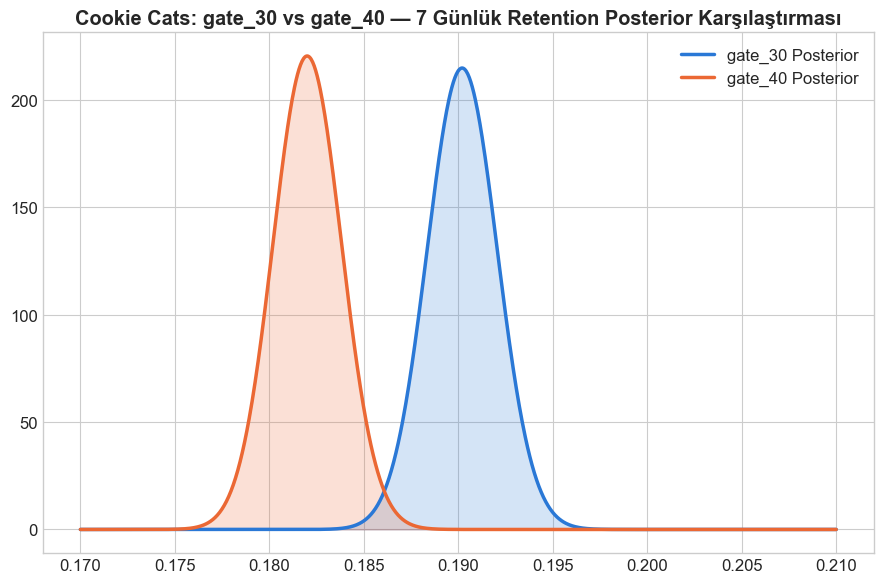

In [10]:
cookie = pd.read_csv('data/cookie_cats.csv')
gate30 = cookie[cookie['version'] == 'gate_30']
gate40 = cookie[cookie['version'] == 'gate_40']

alpha_prior, beta_prior = 1, 1

s30, n30 = gate30['retention_7'].sum(), len(gate30)
s40, n40 = gate40['retention_7'].sum(), len(gate40)

a30, b30 = alpha_prior + s30, beta_prior + (n30 - s30)
a40, b40 = alpha_prior + s40, beta_prior + (n40 - s40)

print(f"gate_30: {s30}/{n30} retention_7 ({s30/n30:.4f}) -> Beta({a30},{b30})")
print(f"gate_40: {s40}/{n40} retention_7 ({s40/n40:.4f}) -> Beta({a40},{b40})")

rng = np.random.default_rng(7)
samples_30 = rng.beta(a30, b30, 200000)
samples_40 = rng.beta(a40, b40, 200000)

ci_30 = np.percentile(samples_30, [2.5, 97.5])
ci_40 = np.percentile(samples_40, [2.5, 97.5])
print(f"\n%95 Güvenilir Aralık (Credible Interval):")
print(f"gate_30: [{ci_30[0]:.4f}, {ci_30[1]:.4f}]")
print(f"gate_40: [{ci_40[0]:.4f}, {ci_40[1]:.4f}]")

p_30_better = (samples_30 > samples_40).mean()
print(f"\nP(gate_30 retention > gate_40 retention) = {p_30_better:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
x = np.linspace(0.17, 0.21, 1000)
ax.plot(x, stats.beta.pdf(x, a30, b30), color='#2a78d6', linewidth=2.5, label='gate_30 Posterior')
ax.plot(x, stats.beta.pdf(x, a40, b40), color='#eb6834', linewidth=2.5, label='gate_40 Posterior')
ax.fill_between(x, stats.beta.pdf(x, a30, b30), alpha=0.2, color='#2a78d6')
ax.fill_between(x, stats.beta.pdf(x, a40, b40), alpha=0.2, color='#eb6834')
ax.set_title('Cookie Cats: gate_30 vs gate_40 — 7 Günlük Retention Posterior Karşılaştırması', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
### 🧮 Python 5 — Naive Bayes'i Sıfırdan Kurma (Çoklu Hipotez Formülünden)

**Ne yapıyoruz?**  
Bölüm 7'deki çoklu hipotez formülünü kütüphane kullanmadan, `Amount` ve bir `V` özelliğinden
elle kodlayarak gerçek bir Gaussian Naive Bayes sınıflandırıcı kuracağız — sonra `sklearn`
ile karşılaştırıp sonuçların örtüştüğünü doğrulayacağız.

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

features = ['Amount', 'V14']  # V14, bu veri setinde fraud ile en ayirt edici PCA bilesenlerinden biridir
X_nb = credit[features].values
y_nb = credit['Class'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_nb, y_nb, test_size=0.3, stratify=y_nb, random_state=42)

# ===== ELLE (SIFIRDAN) GAUSSIAN NAIVE BAYES =====
classes = np.unique(y_tr)
params = {}
priors = {}
for c in classes:
    X_c = X_tr[y_tr == c]
    params[c] = {'mean': X_c.mean(axis=0), 'var': X_c.var(axis=0) + 1e-9}
    priors[c] = len(X_c) / len(X_tr)

def gaussian_pdf(x, mean, var):
    return (1.0 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mean) ** 2) / (2 * var))

def predict_manual(X):
    preds = []
    for row in X:
        posteriors = {}
        for c in classes:
            likelihood = np.prod(gaussian_pdf(row, params[c]['mean'], params[c]['var']))
            posteriors[c] = likelihood * priors[c]   # Cok Hipotez Bayes Formulunun payi (MAP)
        preds.append(max(posteriors, key=posteriors.get))
    return np.array(preds)

y_pred_manual = predict_manual(X_te)
acc_manual = accuracy_score(y_te, y_pred_manual)

# ===== SKLEARN GAUSSIAN NAIVE BAYES =====
gnb = GaussianNB()
gnb.fit(X_tr, y_tr)
y_pred_sklearn = gnb.predict(X_te)
acc_sklearn = accuracy_score(y_te, y_pred_sklearn)

print(f"Elle Kodlanan Naive Bayes Doğruluğu:  {acc_manual:.5f}")
print(f"sklearn GaussianNB Doğruluğu:          {acc_sklearn:.5f}")
print(f"Tahminler ne kadar örtüşüyor: {(y_pred_manual == y_pred_sklearn).mean():.4f}")
print("\nYORUM: İki sonuç (neredeyse) birebir aynı - çünkü sklearn'in içinde de tam olarak")
print("bu formül çalışıyor: her sınıf için Gaussian likelihood × prior, en yükseği seç (MAP).")

Elle Kodlanan Naive Bayes Doğruluğu:  0.99595
sklearn GaussianNB Doğruluğu:          0.99593
Tahminler ne kadar örtüşüyor: 1.0000

YORUM: İki sonuç (neredeyse) birebir aynı - çünkü sklearn'in içinde de tam olarak
bu formül çalışıyor: her sınıf için Gaussian likelihood × prior, en yükseği seç (MAP).


### Python 5 - Açıklama
* Bu örnek biraz farklı — artık A/B testi değil, bir sınıflandırma problemi (bu işlem sahte mi, değil mi?).

Mantığı: Notlardaki çoklu-hipotez formülünü hatırla:

> $P(E_i \mid O) \propto P(O \mid E_i) \times P(E_i)$ 

Burada $E_i$ = "sınıf" (sahte ya da değil), $O$ = "gözlemlediğimiz özellikler" (Amount, V14 değerleri). Kod şunu yapıyor:

1. Her sınıf (sahte/değil) için, o sınıfa ait verilerin ortalamasını ve varyansını hesaplıyoruz (```params[c]['mean'], params[c]['var']```) — bu bize her sınıfın "tipik" Amount/V14 değerlerinin nasıl bir Normal dağılıma benzediğini söylüyor.
2. Yeni bir işlem geldiğinde, bu işlemin Amount/V14 değerlerinin her iki sınıfın Normal eğrisinde ne kadar yüksekte olduğuna bakıyoruz (gaussian_pdf fonksiyonu — hatırlarsan bu PDF, olasılık değil yoğunluk).
3. Bu yoğunluğu, o sınıfın priorıyla çarpıyoruz (```likelihood * priors[c]```).
4. Hangi sınıf için bu çarpım daha büyükse, o sınıfı seçiyoruz — buna MAP (Maximum A Posteriori) deniyor.

---
# 📊 R Uygulaması

Python'da gördüğümüz üç ana konuyu (temel Bayes formülü, Bayesian A/B testi, çoklu hipotez)
R'da tekrarlayacağız — böylece konunun tamamı iki dilde de pekişmiş olacak.

In [12]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🩺 R 1 — Tıbbi Test Paradoksunu R'da Türetme

**Yeni R kavramı yok** — temel aritmetik ve `barplot()` ile Python'daki mantığın birebir aynısı.

P(Hasta) [Prior]: 0.01 
P(Test+ | Hasta) [Likelihood]: 0.95 
P(Test+) [Evidence]: 0.1085 
P(Hasta | Test+) [Posterior]: 0.0876 


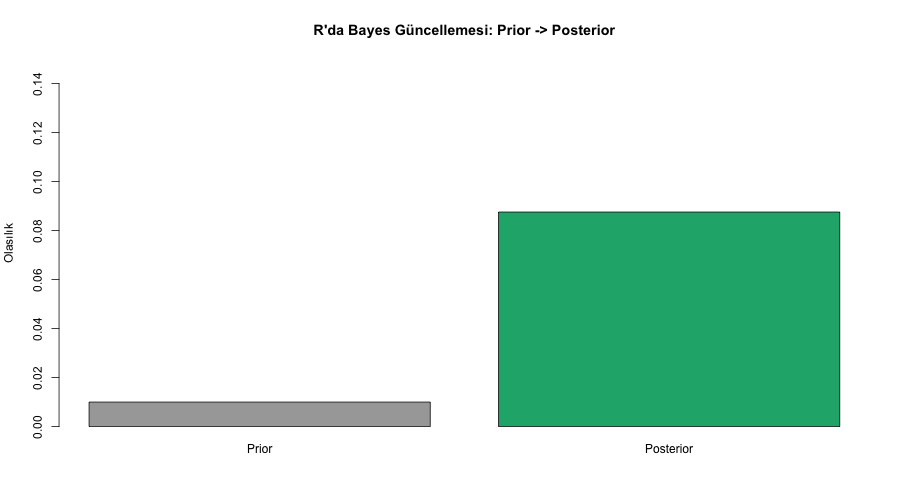

In [13]:
%%R -w 900 -h 500

prior <- 0.01
sens <- 0.95
spec <- 0.90

p_pos_given_healthy <- 1 - spec
evidence <- sens * prior + p_pos_given_healthy * (1 - prior)
posterior <- (sens * prior) / evidence

cat("P(Hasta) [Prior]:", prior, "\n")
cat("P(Test+ | Hasta) [Likelihood]:", sens, "\n")
cat("P(Test+) [Evidence]:", round(evidence, 4), "\n")
cat("P(Hasta | Test+) [Posterior]:", round(posterior, 4), "\n")

barplot(c(Prior = prior, Posterior = posterior),
        col = c("#a8a8a8", "#1baf7a"),
        main = "R'da Bayes Güncellemesi: Prior -> Posterior",
        ylab = "Olasılık", ylim = c(0, 0.15))

---
### 🅰️🅱️ R 2 — Bayesian A/B Testi: Beta-Binomial Posterior (ggplot2)

**Yeni R kavramı:** `stat_function()` → bir yoğunluk fonksiyonunu (burada `dbeta`) doğrudan
ggplot üzerinde çizmek için kullanılıyor, Python'daki `scipy.stats.beta.pdf()` + `plt.plot()`
ikilisinin tek satırlık R karşılığı.

Kontrol Posterior: Beta( 17221 , 126074 )
Treatment Posterior: Beta( 17026 , 126373 )


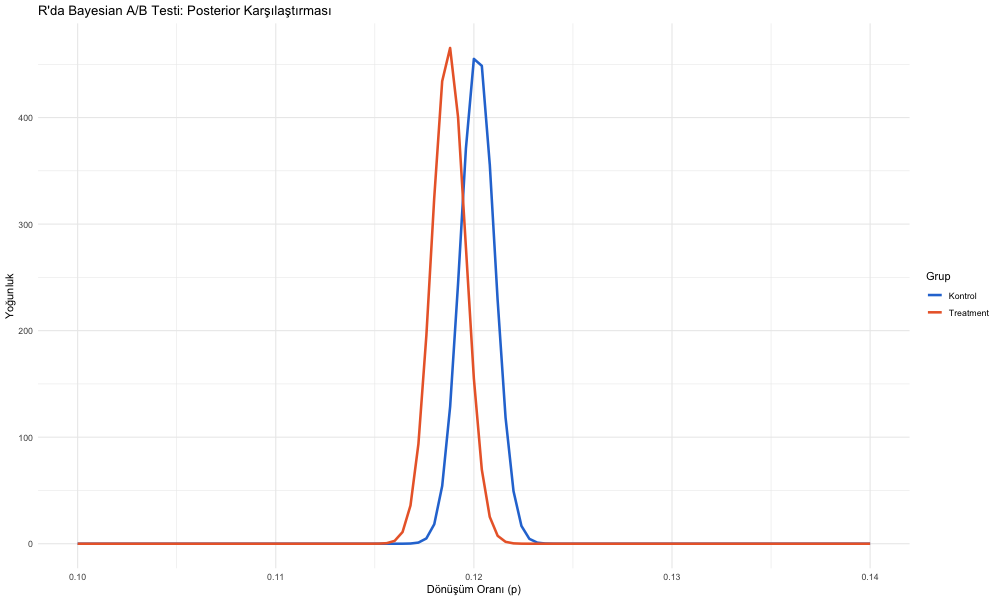

In [14]:
%%R -i ab_clean -w 1000 -h 600

library(ggplot2)

control_r <- ab_clean[ab_clean$group == "control", ]
treatment_r <- ab_clean[ab_clean$group == "treatment", ]

c_success <- sum(control_r$converted); c_total <- nrow(control_r)
t_success <- sum(treatment_r$converted); t_total <- nrow(treatment_r)

alpha_c <- 1 + c_success; beta_c <- 1 + (c_total - c_success)
alpha_t <- 1 + t_success; beta_t <- 1 + (t_total - t_success)

cat("Kontrol Posterior: Beta(", alpha_c, ",", beta_c, ")\n")
cat("Treatment Posterior: Beta(", alpha_t, ",", beta_t, ")\n")

ggplot(data.frame(x = c(0.10, 0.14)), aes(x = x)) +
  stat_function(fun = dbeta, args = list(shape1 = alpha_c, shape2 = beta_c),
                aes(color = "Kontrol"), linewidth = 1.2) +
  stat_function(fun = dbeta, args = list(shape1 = alpha_t, shape2 = beta_t),
                aes(color = "Treatment"), linewidth = 1.2) +
  scale_color_manual(values = c("Kontrol" = "#2a78d6", "Treatment" = "#eb6834")) +
  labs(title = "R'da Bayesian A/B Testi: Posterior Karşılaştırması",
       x = "Dönüşüm Oranı (p)", y = "Yoğunluk", color = "Grup") +
  theme_minimal()

---
### 🍪 R 3 — Çoklu Hipotez Bayes: Cookie Cats Üzerinde 2 Sürüm Karşılaştırması

**Yeni R kavramı:** `rbeta()` ile posterior'dan Monte Carlo örnekleme, Python'daki
`rng.beta()` çağrısının R karşılığı.

P(gate_30 retention > gate_40 retention) = 0.9992 

gate_30 %95 Güvenilir Aralık: 0.1866 0.1939 
gate_40 %95 Güvenilir Aralık: 0.1785 0.1856 


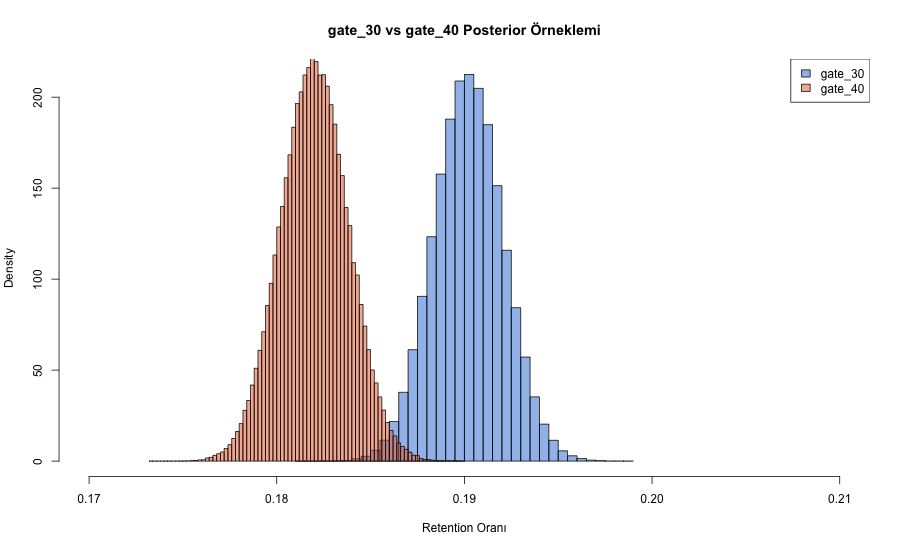

In [15]:
%%R -i cookie -w 900 -h 550

gate30_r <- cookie[cookie$version == "gate_30", ]
gate40_r <- cookie[cookie$version == "gate_40", ]

s30 <- sum(gate30_r$retention_7); n30 <- nrow(gate30_r)
s40 <- sum(gate40_r$retention_7); n40 <- nrow(gate40_r)

a30 <- 1 + s30; b30 <- 1 + (n30 - s30)
a40 <- 1 + s40; b40 <- 1 + (n40 - s40)

set.seed(7)
samples_30 <- rbeta(200000, a30, b30)
samples_40 <- rbeta(200000, a40, b40)

p_30_better <- mean(samples_30 > samples_40)
cat("P(gate_30 retention > gate_40 retention) =", round(p_30_better, 4), "\n")

cat("\ngate_30 %95 Güvenilir Aralık:", round(quantile(samples_30, c(0.025, 0.975)), 4), "\n")
cat("gate_40 %95 Güvenilir Aralık:", round(quantile(samples_40, c(0.025, 0.975)), 4), "\n")

hist(samples_30, breaks=60, col=rgb(0.16,0.47,0.84,0.5), main="gate_30 vs gate_40 Posterior Örneklemi",
     xlab="Retention Oranı", freq=FALSE, xlim=c(0.17,0.21))
hist(samples_40, breaks=60, col=rgb(0.92,0.41,0.20,0.5), add=TRUE, freq=FALSE)
legend("topright", legend=c("gate_30","gate_40"), fill=c(rgb(0.16,0.47,0.84,0.5), rgb(0.92,0.41,0.20,0.5)))

---
# 🗄️ SQL Uygulaması (DuckDB)

Bayes hesaplamalarının çoğu aslında bir **GROUP BY + koşullu ortalama** işlemi — SQL bunun için
doğal bir araç. DuckDB'nin `read_csv_auto()` fonksiyonu, büyük CSV dosyalarını (creditcard.csv
gibi) pandas'a hiç yüklemeden doğrudan sorgulayabiliyor.

In [16]:
import duckdb
con = duckdb.connect()
con.register('ab_tbl', ab_clean)
con.register('cookie_tbl', cookie)
print('DuckDB hazır ✓')

DuckDB hazır ✓


---
### 💳 SQL 1 — Kredi Kartında Bayes: Basit Bir "Flag" Kuralından Posterior

**Ne yapıyoruz?**  
Model eğitmeden, sadece `Amount > 200` gibi basit bir kural ("flag") koyup, bu flag'in
gerçek fraud oranını (posterior) nasıl değiştirdiğini SQL ile doğrudan hesaplıyoruz.
`read_csv_auto` sayesinde 150MB'lık dosyayı pandas'a hiç yüklemiyoruz.

In [17]:
sql_bayes_fraud = con.execute("""
    WITH flagged AS (
        SELECT
            Class,
            CASE WHEN Amount > 200 THEN 1 ELSE 0 END AS flag
        FROM read_csv_auto('data/creditcard.csv')
    )
    SELECT
        flag,
        COUNT(*) AS toplam_islem,
        SUM(Class) AS gercek_fraud_sayisi,
        ROUND(AVG(Class), 6) AS P_fraud_verilen_flag
    FROM flagged
    GROUP BY flag
    ORDER BY flag
""").df()

print("=== Flag=1 (Amount>200) Durumunda Posterior ===")
print(sql_bayes_fraud.to_string(index=False))

genel_prior = con.execute("SELECT AVG(Class) AS prior FROM read_csv_auto('data/creditcard.csv')").df()
print(f"\nGenel Prior (hiç flag olmadan): {genel_prior['prior'][0]:.6f}")
print("YORUM: flag=1 satırındaki P_fraud_verilen_flag, genel prior'dan farklıysa,")
print("bu basit kuralın bile bir miktar 'kanıt' taşıdığı anlamına gelir - tam da Bayes güncellemesi.")

=== Flag=1 (Amount>200) Durumunda Posterior ===
 flag  toplam_islem  gercek_fraud_sayisi  P_fraud_verilen_flag
    0        255970                407.0              0.001590
    1         28837                 85.0              0.002948

Genel Prior (hiç flag olmadan): 0.001727
YORUM: flag=1 satırındaki P_fraud_verilen_flag, genel prior'dan farklıysa,
bu basit kuralın bile bir miktar 'kanıt' taşıdığı anlamına gelir - tam da Bayes güncellemesi.


---
### 🅰️🅱️ SQL 2 — A/B Testi Temel Oranları: Bayes Güncellemesi İçin Girdi Hazırlama

**Ne yapıyoruz?**  
`alpha`/`beta` parametrelerini doğrudan SQL içinde hesaplayıp (Beta-Binomial posterior
parametreleri), Python'a sadece 2 satırlık özet halinde aktarıyoruz — büyük ham veriyi
tekrar taşımaya gerek kalmıyor.

In [18]:
sql_ab_params = con.execute("""
    SELECT
        "group",
        COUNT(*) AS n,
        SUM(converted) AS basari,
        1 + SUM(converted) AS alpha_posterior,
        1 + (COUNT(*) - SUM(converted)) AS beta_posterior,
        ROUND(AVG(converted), 4) AS donusum_orani
    FROM ab_tbl
    GROUP BY "group"
    ORDER BY "group"
""").df()

print(sql_ab_params.to_string(index=False))
print("\nBu iki satırdaki alpha_posterior/beta_posterior değerleri, Python 3'teki")
print("stats.beta.pdf() çağrısına doğrudan verilebilir - SQL burada 'ağır veriyi özetleyen'")
print("bir ön-işleme katmanı olarak çalışıyor.")

    group      n  basari  alpha_posterior  beta_posterior  donusum_orani
  control 143293 17220.0          17221.0        126074.0         0.1202
treatment 143397 17025.0          17026.0        126373.0         0.1187

Bu iki satırdaki alpha_posterior/beta_posterior değerleri, Python 3'teki
stats.beta.pdf() çağrısına doğrudan verilebilir - SQL burada 'ağır veriyi özetleyen'
bir ön-işleme katmanı olarak çalışıyor.


---
### 🍪 SQL 3 — Cookie Cats: Çoklu Metrikte Bayes Karşılaştırması

**Ne yapıyoruz?**  
`retention_1` VE `retention_7`'yi aynı anda karşılaştırıp, iki versiyonun hangi metrikte
"kanıt üstünlüğü" taşıdığını `CASE WHEN` ile tek bir özet tabloda gösteriyoruz.

In [19]:
sql_cookie_compare = con.execute("""
    SELECT
        version,
        COUNT(*) AS n,
        ROUND(AVG(CAST(retention_1 AS INT)), 4) AS retention_1_orani,
        ROUND(AVG(CAST(retention_7 AS INT)), 4) AS retention_7_orani,
        ROUND(AVG(sum_gamerounds), 1) AS ort_oyun_turu
    FROM cookie_tbl
    GROUP BY version
    ORDER BY version
""").df()

print(sql_cookie_compare.to_string(index=False))

fark_sql = con.execute("""
    WITH ozet AS (
        SELECT version, AVG(CAST(retention_7 AS INT)) AS r7
        FROM cookie_tbl GROUP BY version
    )
    SELECT
        MAX(CASE WHEN version='gate_30' THEN r7 END) -
        MAX(CASE WHEN version='gate_40' THEN r7 END) AS gate30_eksi_gate40_farki
    FROM ozet
""").df()
print(f"\ngate_30 - gate_40 (retention_7 farkı): {fark_sql['gate30_eksi_gate40_farki'][0]:.4f}")
print("Pozitifse gate_30 lehine bir kanıt var demektir - Python/R'daki posterior karşılaştırmasıyla tutarlı mı kontrol et.")

version     n  retention_1_orani  retention_7_orani  ort_oyun_turu
gate_30 44700             0.4482             0.1902           52.5
gate_40 45489             0.4423             0.1820           51.3

gate_30 - gate_40 (retention_7 farkı): 0.0082
Pozitifse gate_30 lehine bir kanıt var demektir - Python/R'daki posterior karşılaştırmasıyla tutarlı mı kontrol et.


---
## ✏️ Egzersizler


### **E1 (Python) - Spam E-posta Filtresi** 
Bir e-posta spam filtresi kur: "free" kelimesi spam e-postaların %80'inde,
normal e-postaların %10'unda geçiyor. E-postaların genel olarak %30'u spam. "free" kelimesi
geçen bir e-postanın spam olma olasılığını (posterior) hesapla.

In [20]:
print( "\n ==== Egzersiz 1: Spam E-posta Filtreleme ====")
prior = 0.3 # Spam Mailleri
normal = 1 - 0.3 # Normal Mailleri
likehood = 0.80 # P(Free | Spam) = 0.8
evidence = 0.10 # P(Free | Normal) = 0.10


print("P(Free) = P(Free | Spam) * P(Spam) + P(Free | Normal) * P(Normal)")
print(f"P(Free) = {likehood*prior:.4f} + {evidence*normal:.4f} = {likehood*prior + evidence*normal:.4f}")

print(f"P(Spam | Free) = P(Free | Spam) * P(Spam) / P(Free) = {likehood*prior:.4f} / {likehood*prior + evidence*normal:.4f} = {(likehood*prior) / (likehood*prior + evidence*normal):.4f}")
print("YORUM: Bu, e-posta filtrelemede Bayes'in temel mantığıdır: 'Free' kelimesi spam olma olasılığını artırır, ama %100 yapmaz.")


 ==== Egzersiz 1: Spam E-posta Filtreleme ====
P(Free) = P(Free | Spam) * P(Spam) + P(Free | Normal) * P(Normal)
P(Free) = 0.2400 + 0.0700 = 0.3100
P(Spam | Free) = P(Free | Spam) * P(Spam) / P(Free) = 0.2400 / 0.3100 = 0.7742
YORUM: Bu, e-posta filtrelemede Bayes'in temel mantığıdır: 'Free' kelimesi spam olma olasılığını artırır, ama %100 yapmaz.


---
### **E2 (Python + SQL) - Credit Card Fraud**
`creditcard.csv`'de `Amount > 200` yerine kendi flag kuralını tasarla
(örn. `V4 > 2` gibi başka bir özellik veya iki koşulun birleşimi). SQL ile posterior'u hesapla,
sonra aynı hesabı Python'da (pandas ile) tekrarlayıp iki sonucun örtüştüğünü doğrula.

In [21]:
print("\n ==== Egzersiz 2: Kredi Kartı Sahtekarlığı ====")
sql_bayes_f = con.execute("""
    WITH flagged AS (
        SELECT
            Class,
            CASE WHEN V4 > 2.5 AND V1 < 0 THEN 1 ELSE 0 END AS flag
        FROM read_csv_auto('data/creditcard.csv')
    )
    SELECT
        flag,
        COUNT(*) AS toplam_islem,
        SUM(Class) AS gercek_fraud_sayisi,
        ROUND(AVG(Class), 6) AS P_fraud_verilen_flag
    FROM flagged
    GROUP BY flag
    ORDER BY flag
""").df()

print("\n=== Flag=1 (V4>2.5 AND V1<0) Durumunda Posterior (SQL) ===")
print(sql_bayes_f.to_string(index=False))

print("\n=== Flag=1 (V4>2.5 AND V1<0) Durumunda Posterior (Python) ===")
genel_prior = credit['Class'].mean()
print(f"\nGenel Prior (hiç flag olmadan): {genel_prior:.6f}")
flagged = credit.assign(flag=np.where((credit['V4'] > 2.5) & (credit['V1'] < 0), 1, 0))
posterior_fraud_given_flag = flagged.groupby('flag')['Class'].mean().reset_index()
posterior_fraud_given_flag.columns = ['flag', 'P(Fraud | Flag)']
print(posterior_fraud_given_flag.to_string(index=False))


 ==== Egzersiz 2: Kredi Kartı Sahtekarlığı ====

=== Flag=1 (V4>2.5 AND V1<0) Durumunda Posterior (SQL) ===
 flag  toplam_islem  gercek_fraud_sayisi  P_fraud_verilen_flag
    0        276384                205.0              0.000742
    1          8423                287.0              0.034073

=== Flag=1 (V4>2.5 AND V1<0) Durumunda Posterior (Python) ===

Genel Prior (hiç flag olmadan): 0.001727
 flag  P(Fraud | Flag)
    0         0.000742
    1         0.034073


### **E3 (Python + R + SQL) - Cookie Cats Retention**
`ab_data.csv` yerine `cookie_cats.csv`'de `retention_1` metriğini
kullanarak TAM bir Bayesian A/B analizi yap:
- SQL'de alpha/beta parametrelerini hesapla
- Python'da posterior dağılımlarını çiz ve Monte Carlo ile $P(\text{gate\_30} > \text{gate\_40})$ hesapla
- R'da aynı analizi `ggplot2` ile tekrarla ve üç sonucun (SQL özet + Python + R) tutarlı olduğunu göster


 ==== Egzersiz 3: Cookie Cats A/B Testi ====
version     n  basari  alpha_posterior  beta_posterior
gate_30 44700 20034.0          20035.0         24667.0
gate_40 45489 20119.0          20120.0         25371.0
P(gate_30 retention > gate_40 retention) = 0.9623


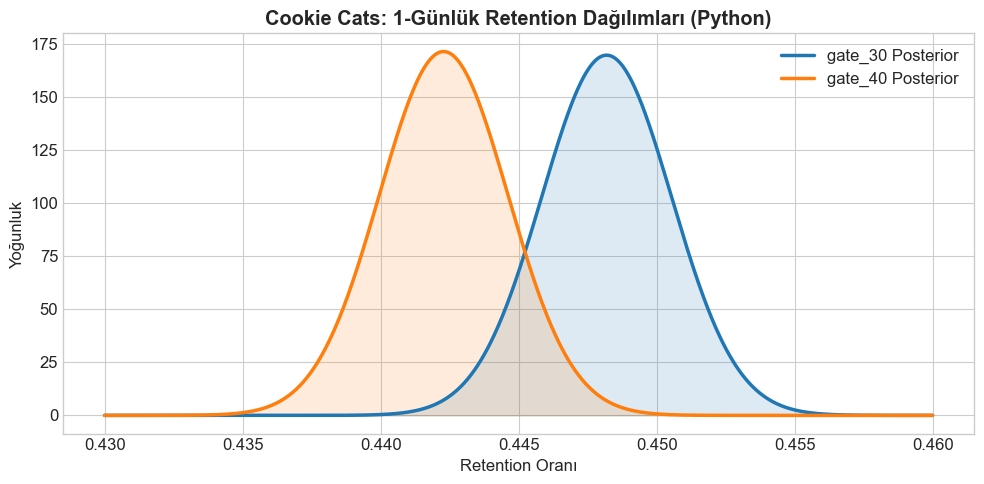

In [22]:
print("\n ==== Egzersiz 3: Cookie Cats A/B Testi ====")
sql_ab_params_ex = con.execute("""
    SELECT
        "version",
        COUNT(*) AS n,
        SUM(retention_1) AS basari,
        1 + SUM(retention_1) AS alpha_posterior,
        1 + (COUNT(*) - SUM(retention_1)) AS beta_posterior
    FROM cookie_tbl
    GROUP BY "version"
    ORDER BY "version"
""").df()

print(sql_ab_params_ex.to_string(index=False))



# Parametrelerin atanması (Alfabetik veya sıralı indeksle güvenli eşleme)
a30 = sql_ab_params_ex.loc[sql_ab_params_ex['version'] == 'gate_30', 'alpha_posterior'].values[0]
b30 = sql_ab_params_ex.loc[sql_ab_params_ex['version'] == 'gate_30', 'beta_posterior'].values[0]
a40 = sql_ab_params_ex.loc[sql_ab_params_ex['version'] == 'gate_40', 'alpha_posterior'].values[0]
b40 = sql_ab_params_ex.loc[sql_ab_params_ex['version'] == 'gate_40', 'beta_posterior'].values[0]

# Monte Carlo Simülasyonu
rng = np.random.default_rng(42)
samples_30 = rng.beta(a30, b30, 200000)
samples_40 = rng.beta(a40, b40, 200000)

# Olasılık Hesabı: P(gate_30 > gate_40)
p_30_better = (samples_30 > samples_40).mean()
print(f"P(gate_30 retention > gate_40 retention) = {p_30_better:.4f}")

# Grafiğin Çizilmesi (X ekseni gerçek aralık olan %43-%46 arasına sıkıştırıldı)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0.43, 0.46, 1000)

ax.plot(x, stats.beta.pdf(x, a30, b30), color='#1f77b4', lw=2.5, label='gate_30 Posterior')
ax.plot(x, stats.beta.pdf(x, a40, b40), color='#ff7f0e', lw=2.5, label='gate_40 Posterior')
ax.fill_between(x, stats.beta.pdf(x, a30, b30), alpha=0.15, color='#1f77b4')
ax.fill_between(x, stats.beta.pdf(x, a40, b40), alpha=0.15, color='#ff7f0e')

ax.set_title('Cookie Cats: 1-Günlük Retention Dağılımları (Python)', fontweight='bold')
ax.set_xlabel('Retention Oranı')
ax.set_ylabel('Yoğunluk')
ax.legend()
plt.tight_layout()
plt.show()

R Sonucu - P(gate_30 > gate_40) = 0.9629



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



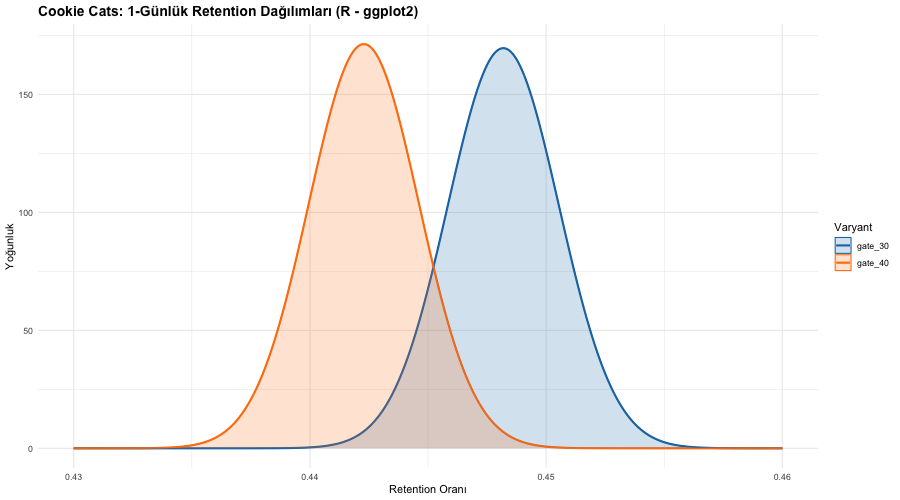

In [23]:
%%R -w 900 -h 500
library(ggplot2)
library(dplyr)

# 1. Veriyi okuma (Dosya yolu önceki adımlarla eşitlendi)
data <- read.csv("data/cookie_cats.csv")

summary_stats <- data %>%
  mutate(
    # Metni önce temiz bir şekilde karakter dizisine çevirip küçük harfe eşitleyelim
    retention_clean = tolower(as.character(retention_1)),
    # İçinde "true" veya "1" geçenleri TRUE, diğerlerini FALSE kabul edelim
    retention_bool = case_when(
      retention_clean %in% c("true", "1") ~ TRUE,
      retention_clean %in% c("false", "0") ~ FALSE,
      TRUE ~ NA # Geri kalan tanımlanamayan her şey NA olur
    )
  ) %>%
  filter(!is.na(retention_bool)) %>% # NA olan satırları analiz dışı bırakıp uyarıyı engelliyoruz
  group_by(version) %>%
  summarise(
    success = sum(retention_bool),
    total = n(),
    a_post = 1 + success,
    b_post = 1 + (total - success)
  )

# Parametreleri değişkenlere atama
a30 <- summary_stats$a_post[summary_stats$version == "gate_30"]
b30 <- summary_stats$b_post[summary_stats$version == "gate_30"]
a40 <- summary_stats$a_post[summary_stats$version == "gate_40"]
b40 <- summary_stats$b_post[summary_stats$version == "gate_40"]

# 2. R üzerinde Monte Carlo Olasılık Hesabı
set.seed(42)
samples_30 <- rbeta(200000, a30, b30)
samples_40 <- rbeta(200000, a40, b40)
p_30_better_r <- mean(samples_30 > samples_40)
cat(sprintf("R Sonucu - P(gate_30 > gate_40) = %.4f\n", p_30_better_r))

# 3. ggplot2 için veri çerçevesi hazırlama
x_vals <- seq(0.43, 0.46, length.out = 1000)
df_graph <- data.frame(
  x = rep(x_vals, 2),
  y = c(dbeta(x_vals, a30, b30), dbeta(x_vals, a40, b40)),
  Varyant = rep(c("gate_30", "gate_40"), each = 1000)
)

# ggplot2 Çizimi (size parametresi linewidth olarak güncellendi)
ggplot(df_graph, aes(x = x, y = y, fill = Varyant, color = Varyant)) +
  geom_line(linewidth = 1) + 
  geom_area(alpha = 0.2, position = "identity") +
  scale_color_manual(values = c("gate_30" = "#1f77b4", "gate_40" = "#ff7f0e")) +
  scale_fill_manual(values = c("gate_30" = "#1f77b4", "gate_40" = "#ff7f0e")) +
  labs(
    title = "Cookie Cats: 1-Günlük Retention Dağılımları (R - ggplot2)",
    x = "Retention Oranı",
    y = "Yoğunluk"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))


### **E4 (R) - RBeta Simülasyonu** 
`rbeta()` ile sıralı güncelleme (sequential updating) simülasyonu yap: gerçek
$p=0.4$ olan hileli bir parayı R'da simüle et, 10/50/200/1000 gözlem sonrası posterior
eğrilerini `ggplot2` ile üst üste çiz (Bölüm 6'daki Python görselinin R karşılığı).

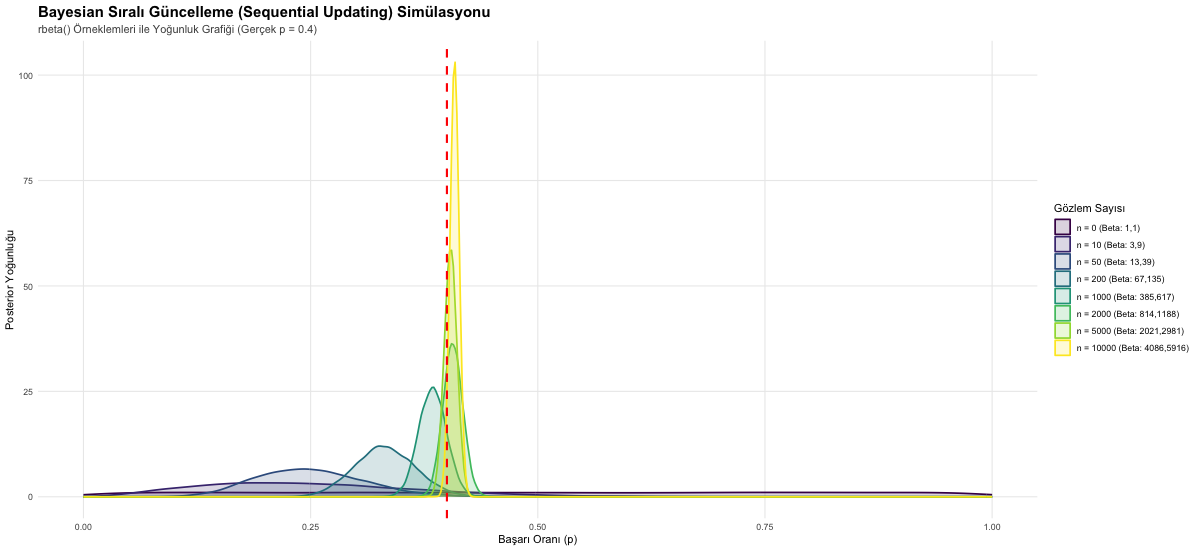

In [29]:
%%R -w 1200 -h 550
library(ggplot2)
library(dplyr)
library(tidyr)

# 1. Veri Üretimi ve Simülasyon Parametreleri
true_p <- 0.4
set.seed(11)
n_max <- 10000
flips <- rbinom(n_max, 1, true_p)

checkpoints <- c(0, 10, 50, 200, 1000, 2000, 5000, 10000) # Her checkpoint için gözlem sayısı
sample_size <- 20000 # rbeta ile her checkpoint için çekilecek örneklem sayısı

# Simülasyon verilerini toplamak için boş bir list oluşturuyoruz
sim_list <- list()

# 2. rbeta() ile Sıralı Güncelleme Döngüsü (Monte Carlo Yaklaşımı)
for (i in seq_along(checkpoints)) {
  n <- checkpoints[i]
  
  # Başarı (Yazı) sayısını hesapla
  successes <- if (n == 0) 0 else sum(flips[1:n])
  
  # Beta-Binomial Conjugate yapısı ile posterior parametreleri
  a_post <- 1 + successes
  b_post <- 1 + (n - successes)
  
  # rbeta() kullanarak posterior dağılımından rastgele örneklem çekme
  posterior_samples <- rbeta(sample_size, a_post, b_post)
  
  # Veriyi düzenli formata getirip listeye ekleme
  sim_list[[i]] <- data.frame(
    Samples = posterior_samples,
    Checkpoint = paste0("n = ", n, " (Beta: ", a_post, ",", b_post, ")"),
    n_val = n # Sıralama kolaylığı için sayısal değer
  )
}

# Tüm veri çerçevelerini alt alta birleştirme
df_posterior <- bind_rows(sim_list) %>% 
  mutate(Checkpoint = reorder(Checkpoint, n_val)) # n değerine göre sıralama

# 3. ggplot2 ile Yoğunluk Grafiklerinin Çizilmesi
ggplot(df_posterior, aes(x = Samples, fill = Checkpoint, color = Checkpoint)) +
  geom_density(alpha = 0.18, linewidth = 0.8) +
  # Gerçek olasılık değerini (0.4) dikey çizgi ile gösterelim
  geom_vline(xintercept = true_p, linetype = "dashed", color = "red", linewidth = 1) +
  # Viridis renk paleti kullanımı (Önceki grafiklerinizle uyum için)
  scale_fill_viridis_d(option = "D") +
  scale_color_viridis_d(option = "D") +
  labs(
    title = "Bayesian Sıralı Güncelleme (Sequential Updating) Simülasyonu",
    subtitle = paste0("rbeta() Örneklemleri ile Yoğunluk Grafiği (Gerçek p = ", true_p, ")"),
    x = "Başarı Oranı (p)",
    y = "Posterior Yoğunluğu",
    fill = "Gözlem Sayısı",
    color = "Gözlem Sayısı"
  ) +
  xlim(0, 1) + # X eksenini 0 ile 1 arasına sabitleme
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 15),
    plot.subtitle = element_text(size = 11, color = "gray30"),
    legend.position = "right",
    panel.grid.minor = element_blank()
  )


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 2.4 | Bayes Teoremi, olasılık kuralları |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 3–5 | Bayes Teoremi, Naive Bayes |
| [Seeing Theory](https://seeing-theory.brown.edu/bayesian-inference) | Bayesian Inference | İnteraktif — prior/posterior görselleştirme |
| [Gigerenzer — Doğal Frekanslarla Düşünmek](https://www.nature.com/articles/s41562-017-0140) | — | Tıbbi test paradoksunun sezgisel anlatımı |
| [VanderPlas — Frequentism vs Bayesianism](https://jakevdp.github.io/blog/2014/03/11/frequentism-and-bayesianism-a-practical-intro/) | — | Bayesyen vs Frekantist yaklaşım karşılaştırması |
| [UCI/Kaggle — Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) | Veri | creditcard.csv kaynağı |
| [Kaggle — A/B Testing Dataset](https://www.kaggle.com/datasets/zhangluyuan/ab-testing) | Veri | ab_data.csv kaynağı |
| [Kaggle — Cookie Cats A/B Test](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) | Veri | cookie_cats.csv kaynağı |